# 08 · Aporte de sexo, edad, antigüedad y ubicación

Comparamos el ensemble 50/50 de logística (36 meses) y XGBoost (toda la historia), con **42 variables transaccionales**, contra ocho ampliaciones del mismo modelo. El experimento mantiene los cuatro bloques temporales de octubre de 2023 a enero de 2025 y seis meses de separación.

Los hiperparámetros históricos no están en esta copia. Se reconstruyó la búsqueda hasta 100 trials de logística y 85 trials finalizados de XGBoost (más uno interrumpido), y se exportó el mejor trial completado con todas las 42 variables. La comparación usa esos parámetros fijos en todas las variantes. **No es necesario ejecutar Optuna para comparar el aporte de variables**; el notebook reutiliza los parámetros exportados. Las siete columnas de campañas del CSV actual no se incorporan. La referencia válida para medir el aporte es la base reentrenada de esta corrida.

**Límite:** ubicación es un snapshot actual; la mejora retrospectiva no garantiza disponibilidad histórica. Las validaciones ya se usaron para tomar decisiones, por lo que no constituyen un test final independiente.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd().resolve()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / 'pyproject.toml').exists():
    raise FileNotFoundError('Abrir el notebook dentro del repositorio')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
OUT = ROOT / 'reports/master_features_comparison_v1'
PARAMS = ROOT / 'reports/master_features_v1/reconstructed_tuning'
from scripts.master_features_ablation import VARIANTS, BASE_COLUMNS
pd.DataFrame([{'variante': name, 'variables_adicionales': ', '.join(cols) or 'Ninguna'}
              for name, cols in VARIANTS.items()])

Matplotlib is building the font cache; this may take a moment.


,variante,variables_adicionales
0,transaccional,Ninguna
1,mas_sexo,sexo
2,mas_edad,edad
3,mas_antiguedad,antiguedad_meses
4,mas_departamento,departamento
5,mas_provincia,provincia
6,mas_ubicacion,"departamento, provincia"
7,mas_demografia_antiguedad,"sexo, edad, antiguedad_meses"
8,mas_todas,"sexo, edad, antiguedad_meses, departamento, pr..."


## 1. Preprocesamiento y separación temporal

Las medianas, categorías y escalado se aprenden dentro de cada entrenamiento, por separado para logística y XGBoost. Edad y antigüedad incluyen un indicador de dato ausente. Se normalizan mayúsculas, tildes y espacios en sexo y ubicación; las categorías desconocidas en validación no se aprenden de ella.

`edad` es la edad al mes observado. `antiguedad_meses` es el tiempo desde la fecha de ingreso registrada, no desde la primera compra. No añadimos tipo de vendedora, identificadores ni información futura.

In [2]:
import inspect
from scripts.master_features_ablation import MasterFeatures, preprocessor, development_data
print(inspect.getsource(MasterFeatures))
print(inspect.getsource(preprocessor))
pool, folds = development_data()
print('Pool de desarrollo:', len(pool), 'filas; último mes:', pool.mes_obs.max().date())
print('Variables base antes de derivadas:', len(BASE_COLUMNS))

class MasterFeatures(TransformerMixin, BaseEstimator):
    """Explicit schema: never ingest new columns or labels accidentally."""

    def __init__(self, extras=()):
        self.extras = extras

    def fit(self, X, y=None):
        self.columns_ = self.transform(X).columns.tolist()
        return self

    def transform(self, X):
        if not set(self.extras).issubset(NUMERIC_MASTER + CATEGORICAL_MASTER):
            raise ValueError("Unsupported master feature")
        d = X[BASE_COLUMNS].copy()
        d[ZERO] = d[ZERO].fillna(0)
        d = engineer(d)
        check_numeric(d)
        for col in self.extras:
            if col in NUMERIC_MASTER:
                d[col] = pd.to_numeric(X[col], errors="raise")
                d[f"{col}_sin_dato"] = d[col].isna().astype(float)
            else:
                d[col] = X[col].map(normalize_category)
        return d

def preprocessor(frame, extras):
    categorical = [c for c in extras if c in CATEGORICAL_MASTER]
    numeric = [c 

## 2. Ejecutar o reanudar

La ejecución reutiliza los parámetros exportados y persiste predicciones por fold; no vuelve a ejecutar Optuna. El manifiesto impide reutilizar resultados si cambia el código, dataset, versiones o protocolo. Un bloqueo impide dos ejecuciones simultáneas. No modificar `EJECUTAR` para consultar los resultados ya calculados.

Solo se ajustan las nueve variantes con los parámetros fijos. No se accede a BigQuery ni se evalúan períodos posteriores a enero de 2025.

In [3]:
EJECUTAR = False
if EJECUTAR:
    import argparse
    import fcntl
    from scripts.master_features_ablation import run
    OUT.mkdir(parents=True, exist_ok=True)
    args = argparse.Namespace(output=str(OUT), params_dir=str(PARAMS), trials=100, threads=4)
    with (OUT / 'runner.lock').open('w') as lock:
        fcntl.flock(lock, fcntl.LOCK_EX | fcntl.LOCK_NB)
        run(args)
else:
    print('Modo lectura de resultados; activar EJECUTAR para entrenar o reanudar.')

Modo lectura de resultados; activar EJECUTAR para entrenar o reanudar.


## 3. Calidad de datos y fechas efectivas

In [4]:
display(pd.read_csv(OUT / 'data_profile.csv'))
display(pd.read_csv(OUT / 'folds.csv'))
import json
parameter_source = json.loads((OUT / 'parameter_source.json').read_text())
print('Origen de los parámetros:', parameter_source['kind'])
display(pd.DataFrame(parameter_source['parameters']).T)


,variable,missing,missing_fraction,distinct_raw
0,edad,16381,0.578609,73
1,antiguedad_meses,88,0.003108,99
2,sexo,0,0.000000,3
3,departamento,30,0.001060,34
4,provincia,30,0.001060,157


,fold,model,train_start,train_end,n_train,valid_start,valid_end,n_valid
0,0,logreg,2020-04-01,2023-03-01,7942,2023-10-01,2024-01-01,1224
1,0,xgboost,2016-12-01,2023-03-01,22492,2023-10-01,2024-01-01,1224
2,1,logreg,2020-08-01,2023-07-01,8619,2024-02-01,2024-05-01,1006
3,1,xgboost,2016-12-01,2023-07-01,23426,2024-02-01,2024-05-01,1006
4,2,logreg,2020-12-01,2023-11-01,9117,2024-06-01,2024-09-01,1110
5,2,xgboost,2016-12-01,2023-11-01,24594,2024-06-01,2024-09-01,1110
6,3,logreg,2021-04-01,2024-03-01,9212,2024-10-01,2025-01-01,1039
7,3,xgboost,2016-12-01,2024-03-01,25637,2024-10-01,2025-01-01,1039


Origen de los parámetros: supplied


,features,balance,C,l1_ratio,n_estimators,max_depth,learning_rate,min_child_weight,subsample,colsample_bytree,reg_alpha,reg_lambda,gamma
logreg,all,True,1.224031,0.588628,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
xgboost,all,True,NaN,NaN,1000,3,0.006249,74.688833,0.797182,0.915885,3.308422,13.982859,2.486928


## 4. Comparación principal

AUC y average precision son medias no ponderadas de los cuatro bloques. Precisión y recall acumulan observaciones; lift promedia los valores mensuales. El top se calcula dentro de cada mes, con redondeo hacia abajo.

,variant,extras,auc_mean,auc_std,ap_mean,precision_top10,recall_top10,lift_top10,precision_top20,recall_top20,lift_top20,precision_top30,recall_top30,lift_top30,delta_auc
0,transaccional,NaN,0.78988,0.00645,0.59621,0.68445,0.21901,2.25675,0.62759,0.40535,2.06519,0.57351,0.55605,1.88477,0.00000
1,mas_sexo,sexo,0.78983,0.00615,0.59590,0.68677,0.21975,2.26490,0.62644,0.40460,2.06223,0.57351,0.55605,1.88430,-0.00005
2,mas_antiguedad,antiguedad_meses,0.78973,0.00618,0.59523,0.68213,0.21826,2.25065,0.62989,0.40683,2.07254,0.57504,0.55754,1.88796,-0.00015
3,mas_demografia_antiguedad,"sexo, edad, antiguedad_meses",0.78899,0.00584,0.59371,0.67749,0.21678,2.23063,0.62759,0.40535,2.06588,0.57580,0.55828,1.89031,-0.00089
4,mas_edad,edad,0.78893,0.00616,0.59493,0.67749,0.21678,2.22598,0.62414,0.40312,2.05549,0.57504,0.55754,1.88692,-0.00095
5,mas_departamento,departamento,0.78892,0.00503,0.58771,0.67749,0.21678,2.22507,0.61724,0.39866,2.03084,0.58040,0.56273,1.90925,-0.00096
6,mas_provincia,provincia,0.78658,0.00620,0.58421,0.68910,0.22049,2.25560,0.61379,0.39644,2.01540,0.57121,0.55382,1.88236,-0.00330
7,mas_ubicacion,"departamento, provincia",0.78648,0.00557,0.58302,0.67981,0.21752,2.21958,0.61494,0.39718,2.01855,0.57044,0.55308,1.88032,-0.00340
8,mas_todas,"sexo, edad, antiguedad_meses, departamento, pr...",0.78572,0.00503,0.58136,0.66821,0.21381,2.17542,0.62299,0.40238,2.04651,0.57198,0.55457,1.88097,-0.00416


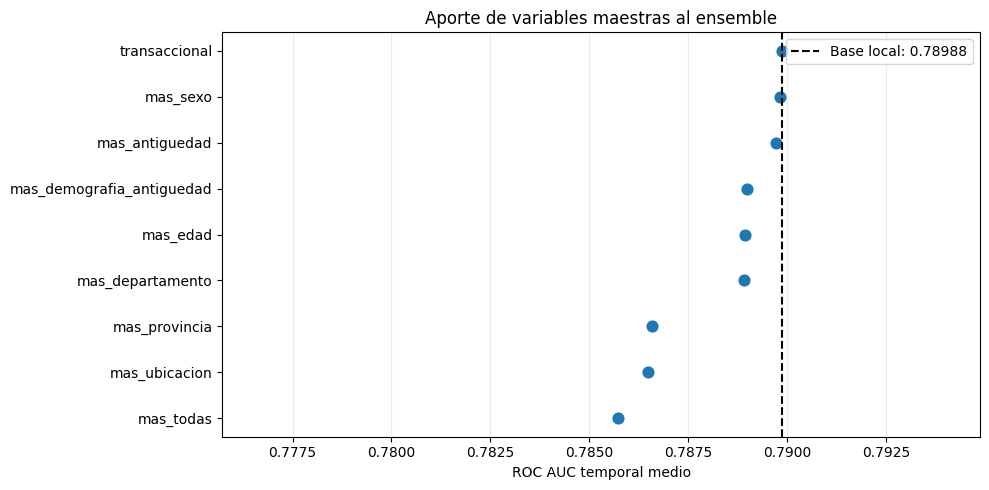

In [5]:
comparison = pd.read_csv(OUT / 'comparison.csv')
display(comparison.round(5))
fig, ax = plt.subplots(figsize=(10, 5))
ordered = comparison.sort_values('auc_mean')
ax.scatter(ordered.auc_mean, ordered.variant, s=60)
ax.grid(axis='x', alpha=.25)
baseline = comparison.loc[comparison.variant == 'transaccional', 'auc_mean'].iloc[0]
ax.axvline(baseline, color='black', linestyle='--', label=f'Base local: {baseline:.5f}')
ax.set(xlabel='ROC AUC temporal medio', title='Aporte de variables maestras al ensemble')
ax.set_xlim(max(0, ordered.auc_mean.min() - .01), min(1, ordered.auc_mean.max() + .005))
ax.legend()
plt.tight_layout()
plt.show()

### AUC de cada componente
Permite distinguir el efecto de las variables sobre logística de 36 meses y sobre XGBoost, además del promedio combinado.

In [6]:
import numpy as np
from sklearn.metrics import roc_auc_score
component_rows = []
for variant in VARIANTS:
    files = sorted(OUT.glob(f'predictions_{variant}_fold*.parquet'))
    assert len(files) == 4, variant
    pred = pd.concat([pd.read_parquet(file) for file in files], ignore_index=True)
    row = {'variant': variant}
    for model, column in [('logreg_36m', 'score_logreg'), ('xgboost_all', 'score_xgboost')]:
        row[model] = np.mean([roc_auc_score(g.churn, g[column]) for _, g in pred.groupby('fold')])
    component_rows.append(row)
component_results = pd.DataFrame(component_rows)
component_results.to_csv(OUT / 'component_metrics.csv', index=False)
display(component_results.round(5))

,variant,logreg_36m,xgboost_all
0,transaccional,0.78763,0.78834
1,mas_sexo,0.78758,0.78815
2,mas_edad,0.78628,0.78790
3,mas_antiguedad,0.78769,0.78808
4,mas_departamento,0.78582,0.78815
5,mas_provincia,0.77792,0.78829
6,mas_ubicacion,0.77770,0.78833
7,mas_demografia_antiguedad,0.78630,0.78786
8,mas_todas,0.77666,0.78769


## 5. Consistencia entre bloques y desempeño mensual

In [7]:
blocks = pd.read_csv(OUT / 'block_metrics.csv')
auc_by_fold = blocks.pivot(index='variant', columns='fold', values='auc')
display(auc_by_fold.round(5))
display(auc_by_fold.subtract(auc_by_fold.loc['transaccional']).round(5))
monthly = pd.read_csv(OUT / 'monthly_metrics.csv')
winner = comparison.iloc[0]['variant']
display(monthly[(monthly.variant == winner) & (monthly.top_fraction == .2)].round(4))

fold,0,1,2,3
variant,,,,
mas_antiguedad,0.78564,0.79449,0.78188,0.79692
mas_demografia_antiguedad,0.78521,0.79440,0.78141,0.79495
mas_departamento,0.78568,0.79224,0.78256,0.79520
mas_edad,0.78454,0.79480,0.78124,0.79515
mas_provincia,0.78050,0.78864,0.78138,0.79582
mas_sexo,0.78584,0.79483,0.78192,0.79674
mas_todas,0.78101,0.78846,0.78081,0.79261
mas_ubicacion,0.78106,0.78930,0.78133,0.79423
transaccional,0.78535,0.79493,0.78187,0.79737


fold,0,1,2,3
variant,,,,
mas_antiguedad,0.00029,-0.00045,0.00002,-0.00045
mas_demografia_antiguedad,-0.00013,-0.00053,-0.00046,-0.00242
mas_departamento,0.00034,-0.00269,0.00069,-0.00217
mas_edad,-0.00081,-0.00014,-0.00063,-0.00222
mas_provincia,-0.00485,-0.00629,-0.00049,-0.00155
mas_sexo,0.00049,-0.00011,0.00005,-0.00063
mas_todas,-0.00434,-0.00648,-0.00105,-0.00476
mas_ubicacion,-0.00429,-0.00563,-0.00054,-0.00314
transaccional,0.00000,0.00000,0.00000,0.00000


,month,top_fraction,n,n_top,positives,tp,precision,recall,lift,variant
1,2023-10-01,0.2,301,60,77,32,0.5333,0.4156,2.0848,transaccional
4,2023-11-01,0.2,361,72,139,46,0.6389,0.3309,1.6593,transaccional
7,2023-12-01,0.2,309,61,114,48,0.7869,0.4211,2.1329,transaccional
10,2024-01-01,0.2,253,50,81,32,0.6400,0.3951,1.9990,transaccional
13,2024-02-01,0.2,239,47,57,21,0.4468,0.3684,1.8735,transaccional
16,2024-03-01,0.2,242,48,70,30,0.6250,0.4286,2.1607,transaccional
19,2024-04-01,0.2,258,51,82,36,0.7059,0.4390,2.2209,transaccional
22,2024-05-01,0.2,267,53,76,32,0.6038,0.4211,2.1212,transaccional
25,2024-06-01,0.2,250,50,56,23,0.4600,0.4107,2.0536,transaccional
28,2024-07-01,0.2,283,56,73,38,0.6786,0.5205,2.6306,transaccional


## 6. Resultado, variables exportadas y límites

In [8]:
import json
display(Markdown((ROOT / '07_results/ablacion_datos_maestros.md').read_text()))
manifest = json.loads((OUT / 'candidate.json').read_text())
print('Candidato:', manifest['variant'])
print('Variables adicionales:', manifest['extras'])
for model, features in manifest['encoded_features'].items():
    print(model, len(features), 'columnas codificadas')
    print(features)

# Aporte de sexo, edad, antigüedad y ubicación al ensemble

La base con **42 variables transaccionales** obtuvo el mayor AUC temporal medio: **0,78988**. Ninguna de las ocho ampliaciones la superó con los parámetros fijos de esta comparación. Con las cinco variables nuevas juntas, el AUC fue **0,78572** (cambio: **−0,00416**).

## Comparación controlada

| variant                   |   auc_mean |   delta_auc |   ap_mean |   precision_top10 |   recall_top10 |   lift_top10 |
|:--------------------------|-----------:|------------:|----------:|------------------:|---------------:|-------------:|
| transaccional             |    0.78988 |     0.00000 |   0.59621 |           0.68445 |        0.21901 |      2.25675 |
| mas_sexo                  |    0.78983 |    -0.00005 |   0.59590 |           0.68677 |        0.21975 |      2.26490 |
| mas_antiguedad            |    0.78973 |    -0.00015 |   0.59523 |           0.68213 |        0.21826 |      2.25065 |
| mas_demografia_antiguedad |    0.78899 |    -0.00089 |   0.59371 |           0.67749 |        0.21678 |      2.23063 |
| mas_edad                  |    0.78893 |    -0.00095 |   0.59493 |           0.67749 |        0.21678 |      2.22598 |
| mas_departamento          |    0.78892 |    -0.00096 |   0.58771 |           0.67749 |        0.21678 |      2.22507 |
| mas_provincia             |    0.78658 |    -0.00330 |   0.58421 |           0.68910 |        0.22049 |      2.25560 |
| mas_ubicacion             |    0.78648 |    -0.00340 |   0.58302 |           0.67981 |        0.21752 |      2.21958 |
| mas_todas                 |    0.78572 |    -0.00416 |   0.58136 |           0.66821 |        0.21381 |      2.17542 |

Todas las variantes usan las mismas 42 variables transaccionales, logística con 36 meses,
XGBoost con toda la historia permitida y promedio 50/50. Los parámetros se fijan antes
de la ablación; no se retunean por variante. Las columnas de campañas no se incorporan.
Origen de parámetros: `supplied`; consultar `parameter_source.json`.
La búsqueda reconstruida terminó 100 trials de logística (77 completos y 23 podados) y 85 de XGBoost (45 completos y 40 podados). Se interrumpió intencionalmente el siguiente trial de XGBoost para priorizar la comparación; ese trial no participó en la selección. Se exportó el mejor trial completo con las 42 variables para cada algoritmo.
No es necesario ejecutar 100 trials para esta comparación: basta con parámetros fijos
y una base evaluada en los mismos períodos. La búsqueda previa se conserva como antecedente.

Cuatro bloques de validación de cuatro meses entre octubre de 2023 y enero de 2025,
gap de seis meses y 4379 observaciones vendedora-mes. El corte se fija por fecha;
no se desplaza con los meses adicionales del CSV actual. No se evalúa el OOT.

## AUC por bloque

| variant                   |       0 |       1 |       2 |       3 |
|:--------------------------|--------:|--------:|--------:|--------:|
| mas_antiguedad            | 0.78564 | 0.79449 | 0.78188 | 0.79692 |
| mas_demografia_antiguedad | 0.78521 | 0.79440 | 0.78141 | 0.79495 |
| mas_departamento          | 0.78568 | 0.79224 | 0.78256 | 0.79520 |
| mas_edad                  | 0.78454 | 0.79480 | 0.78124 | 0.79515 |
| mas_provincia             | 0.78050 | 0.78864 | 0.78138 | 0.79582 |
| mas_sexo                  | 0.78584 | 0.79483 | 0.78192 | 0.79674 |
| mas_todas                 | 0.78101 | 0.78846 | 0.78081 | 0.79261 |
| mas_ubicacion             | 0.78106 | 0.78930 | 0.78133 | 0.79423 |
| transaccional             | 0.78535 | 0.79493 | 0.78187 | 0.79737 |

## Resultado de cada componente

| variant                   |   logreg_36m |   xgboost_all |
|:--------------------------|-------------:|--------------:|
| transaccional             |      0.78763 |       0.78834 |
| mas_sexo                  |      0.78758 |       0.78815 |
| mas_edad                  |      0.78628 |       0.78790 |
| mas_antiguedad            |      0.78769 |       0.78808 |
| mas_departamento          |      0.78582 |       0.78815 |
| mas_provincia             |      0.77792 |       0.78829 |
| mas_ubicacion             |      0.77770 |       0.78833 |
| mas_demografia_antiguedad |      0.78630 |       0.78786 |
| mas_todas                 |      0.77666 |       0.78769 |

La caída al añadir ubicación se concentra en logística: de **0,78763** a **0,77770** al añadir departamento y provincia. XGBoost se mantiene prácticamente igual: **0,78834** frente a **0,78833**. Esta prueba mantiene la regularización y los otros parámetros fijos; no demuestra que esas variables sean inútiles bajo cualquier configuración.

Las métricas de contacto no cambian todas en el mismo sentido: sexo mejora ligeramente el lift top 10 % (2,26490× frente a 2,25675×), aunque no el AUC. La elección de esta comparación sigue el criterio original de AUC temporal medio; no se ha demostrado significancia estadística de esas diferencias.

## Tratamiento y límites

- Edad y antigüedad: mediana aprendida exclusivamente en cada entrenamiento e indicador
  explícito de dato ausente. Edad se refiere al mes observado, a partir de fecha de nacimiento;
  antigüedad es meses desde la fecha de ingreso registrada.
- Sexo, departamento y provincia: normalización de espacios, mayúsculas y tildes;
  one-hot aprendido en entrenamiento, categorías nuevas ignoradas. Faltantes tienen categoría propia.
- La imputación, vocabulario y escalado se ajustan por separado para cada modelo y fold.
- Ubicación es departamento/provincia del snapshot actual. Una mejora retrospectiva no
  acredita que esa ubicación estuviera disponible en la fecha histórica. Lo mismo exige
  verificar la calidad de sexo, nacimiento e ingreso antes de una decisión operativa.
- Son métricas de selección sobre validaciones reutilizadas. Las pequeñas diferencias no
  demuestran superioridad estadística ni equivalen a una evaluación final independiente.
- La referencia histórica de AUC 0,78961 procede de otra corrida. La comparación del aporte
  de añadir variables se realiza contra `transaccional` de esta misma ejecución.

## Calidad de los datos de desarrollo

| variable         |   missing |   faltantes_pct |
|:-----------------|----------:|----------------:|
| edad             |     16381 |           57.86 |
| antiguedad_meses |        88 |            0.31 |
| sexo             |         0 |            0    |
| departamento     |        30 |            0.11 |
| provincia        |        30 |            0.11 |

## Verificación

Pasaron 18 pruebas automatizadas. Se recalcularon los AUC desde las predicciones guardadas, se verificó la alineación de las 4.379 filas entre las nueve variantes y el promedio 50/50. El hash del candidato coincide con su manifiesto y su inferencia funciona al cargarlo en un proceso nuevo.

## Artefactos

En `reports/master_features_comparison_v1`: protocolo con hashes/versiones,
parámetros, perfil de faltantes, fechas de folds, predicciones por variante/fold,
`comparison.csv`, `block_metrics.csv`, `monthly_metrics.csv`, `candidate.json` y
`candidate.joblib`. El candidato se guarda por separado del ensemble histórico y su recarga
se comprueba. Las métricas de precisión y recall son agregadas; el lift es promedio mensual.

Ejecución y análisis: [notebook 08](../05_modelling/08_ablacion_datos_maestros.ipynb).


Candidato: transaccional
Variables adicionales: []
logreg 42 columnas codificadas
['meses_activos_u3', 'meses_activos_u6', 'meses_activos_u12', 'n_ped_u3', 'n_ped_u6', 'n_ped_u12', 'monto_u3', 'monto_u6', 'monto_u12', 'monto_mean_u12', 'monto_std_u12', 'monto_cv_u12', 'monto_ult_vs_media', 'meses_desde_compra_previa', 'compras_hist', 'n_prod_u12', 'n_cat_max_u12', 'tend_monto_u3_vs_prev3', 'tend_nped_u3_vs_prev3', 'monto_acum', 'n_ped_acum', 'n_prod_acum', 'n_cat_max_acum', 'ticket_acum', 'monto_por_prod_acum', 'monto_mensual_acum', 'd_monto_m1', 'd_monto_m3', 'd_monto_m6', 'd_monto_m9', 'd_monto_m12', 'd_nped_m1', 'd_nped_m3', 'd_nped_m6', 'd_nped_m9', 'd_nped_m12', 'ticket_prom_u12', 'ticket_prom_u3', 'intensidad_u3', 'basket_size_u12', 'recencia_norm', 'tasa_act_reciente_vs_hist']
xgboost 42 columnas codificadas
['meses_activos_u3', 'meses_activos_u6', 'meses_activos_u12', 'n_ped_u3', 'n_ped_u6', 'n_ped_u12', 'monto_u3', 'monto_u6', 'monto_u12', 'monto_mean_u12', 'monto_std_u12', 'm